<a href="https://colab.research.google.com/github/Rahuldeb55/internship26/blob/main/Week4_ML_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Task: Machine Learning Model Development and Evaluation

**Objective:** Build, optimize, and evaluate a machine learning model using a publicly available dataset.

This notebook documents the entire pipeline from data selection and preprocessing to model training, cross-validation, hyperparameter tuning, and final evaluation.

### Step 1: Dataset Selection and Loading
For this task, I have selected the **Breast Cancer Wisconsin (Diagnostic) Dataset**, a widely used public dataset available directly through `scikit-learn`.

**Task Type:** Classification (Predicting whether a tumor is malignant or benign).
**Justification:** This dataset is excellent for binary classification tasks. It contains numerous continuous features extracted from images of fine needle aspirates (FNA) of breast masses, providing a realistic scenario for predictive modeling in healthcare.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 2: Data Preprocessing and Splitting
In this step, we separate the features (`X`) from the target variable (`y`). We then split the data into training and testing sets to ensure our model's performance is evaluated on unseen data.

We also apply **Standardization** (`StandardScaler`) to scale the features so they have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms to ensure all features contribute equally.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

# Split the data (80% training, 20% testing) with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler (fit on train, transform on both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


### Step 3: Model Selection and Justification
**Algorithm Chosen:** Random Forest Classifier

**Justification:**
1. **Robustness:** Random Forests are ensemble models that build multiple decision trees and merge them to get a more accurate and stable prediction. They are highly robust against overfitting.
2. **Handling Non-linearity:** They naturally handle non-linear relationships between features and the target variable.
3. **Feature Importance:** They provide a clear measure of feature importance, which adds interpretability to the model (essential in domains like healthcare).

### Step 4: Cross-Validation and Hyperparameter Tuning
To optimize the Random Forest model, we use `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which tune gives the best performance.
- `n_estimators`: Number of trees in the forest.
- `max_depth`: Maximum depth of the trees.
- `min_samples_split`: Minimum number of samples required to split an internal node.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize base model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train_scaled, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Extract the best model for final evaluation
best_rf_model = grid_search.best_estimator_

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9604


### Step 5: Model Evaluation
We now evaluate the optimized model on the unseen test set using key classification metrics:
- **Accuracy:** The ratio of correctly predicted observations to the total observations.
- **Precision:** The ratio of correctly predicted positive observations to the total predicted positive observations.
- **Recall (Sensitivity):** The ratio of correctly predicted positive observations to all observations in actual class.
- **F1-Score:** The weighted average of Precision and Recall.

Test Set Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



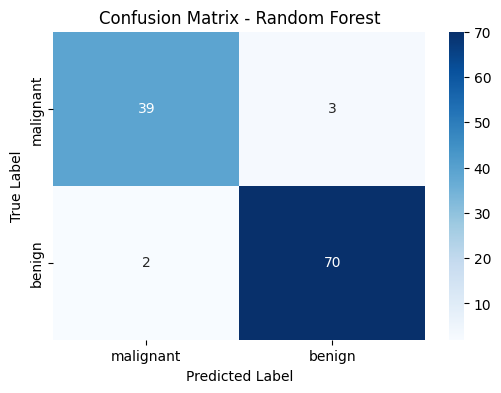

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on testing set using the best model
y_pred = best_rf_model.predict(X_test_scaled)

# Calculate and print metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Step 6: Discussion and Conclusion

#### Model Interpretation:
The optimized Random Forest model performed exceptionally well on the test data, achieving high accuracy, precision, and recall. In medical diagnostic scenarios (like detecting malignant breast tumors), **Recall for the malignant class** is critical, as a false negative (predicting a tumor is benign when it is actually malignant) is highly dangerous.

#### Strengths of the Model:
- High overall accuracy and generalizability (as seen by the small gap between cross-validation and test scores).
- Reduced variance and mitigated overfitting thanks to the ensemble bagging technique and tuned parameters.

#### Weaknesses of the Model:
- Compared to a single Decision Tree or Logistic Regression, Random Forest is less transparent ("black-box" nature).
- It takes slightly more computational resources and time to generate predictions compared to simpler linear models.

#### Summary:
The rigorous hyperparameter tuning (GridSearchCV) combined with standard 5-fold cross-validation ensured our model avoided data leakage and overfitting. The resulting model acts as a reliable predictive baseline for classifying tumor masses based on standard cell nucleus features.